In [4]:
!nvidia-smi

import os, random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("Torch:", torch.__version__)

Sat Feb 21 22:48:11 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   51C    P8             13W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [41]:
# =========================
# Cell 2 — Load CSVs (from Colab environment) + Merge + Basic Cleaning
# =========================

import pandas as pd
import numpy as np

train = pd.read_csv("/content/train.csv", low_memory=False)
store = pd.read_csv("/content/store.csv")

print("Train shape:", train.shape)
print("Store shape:", store.shape)

# -------------------------
# Basic Cleaning
# -------------------------

# تبدیل تاریخ
train["Date"] = pd.to_datetime(train["Date"])

# اصلاح ستون StateHoliday (ترکیبی عدد و رشته)
train["StateHoliday"] = train["StateHoliday"].astype(str)
train["StateHoliday"] = train["StateHoliday"].replace({"0.0": "0"})

# تبدیل ستون‌های باینری به عددی
for col in ["Open", "Promo", "SchoolHoliday"]:
    train[col] = pd.to_numeric(train[col], errors="coerce")

# -------------------------
# Merge store info
# -------------------------
df = train.merge(store, on="Store", how="left")

print("Merged shape:", df.shape)

# بررسی اولیه
print("Date range:", df["Date"].min(), "→", df["Date"].max())
print("Number of stores:", df["Store"].nunique())
print("Missing store info rows:", df["StoreType"].isna().sum())

display(df.head())

Train shape: (1001599, 10)
Store shape: (1115, 10)
Merged shape: (1001599, 19)
Date range: 2013-01-01 00:00:00 → 2015-07-17 00:00:00
Number of stores: 1115
Missing store info rows: 0


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Id,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-17,4852,519,1,1,0,0,303445,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-17,4518,495,1,1,0,1,959585,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-17,6679,673,1,1,0,1,739744,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-17,10514,1343,1,1,0,1,864001,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-17,4355,513,1,1,0,1,981931,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [42]:
# =========================
# Cell 3 — Time Features + Clean Closed Days + Basic Imputation
# =========================

df = df.sort_values(["Store", "Date"]).reset_index(drop=True)

# 1) Remove closed days (Open==0) where Sales is usually 0 (helps forecasting)
#    We keep rows with Open==1 OR (Open is missing but Sales>0) just in case.
df = df[(df["Open"] == 1) | (df["Open"].isna() & (df["Sales"] > 0))].copy()
df = df.reset_index(drop=True)

# 2) Time features
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)
df["IsMonthStart"] = df["Date"].dt.is_month_start.astype(int)
df["IsMonthEnd"] = df["Date"].dt.is_month_end.astype(int)

# Optional: cyclic encoding (keeps seasonality smooth)
df["Month_sin"] = np.sin(2 * np.pi * df["Month"] / 12.0)
df["Month_cos"] = np.cos(2 * np.pi * df["Month"] / 12.0)
df["DOW_sin"]   = np.sin(2 * np.pi * df["DayOfWeek"] / 7.0)
df["DOW_cos"]   = np.cos(2 * np.pi * df["DayOfWeek"] / 7.0)

# 3) Store-related feature: competition open duration (in months) — SAFE version
comp_year = pd.to_numeric(df["CompetitionOpenSinceYear"], errors="coerce").fillna(0).astype(int)
comp_month = pd.to_numeric(df["CompetitionOpenSinceMonth"], errors="coerce").fillna(0).astype(int)

# month index for date and competition start (approx month resolution)
date_month_index = df["Date"].dt.year * 12 + df["Date"].dt.month

# if year/month is 0 -> treat as unknown and set months=0
comp_month_index = comp_year * 12 + comp_month
comp_month_index = comp_month_index.where((comp_year > 0) & (comp_month > 0), other=np.nan)

df["CompOpenMonths"] = (date_month_index - comp_month_index).astype("float32")
df["CompOpenMonths"] = df["CompOpenMonths"].fillna(0.0)
df.loc[df["CompOpenMonths"] < 0, "CompOpenMonths"] = 0.0

# 4) PromoInterval -> number of months promoted (0 if NaN)
df["PromoInterval"] = df["PromoInterval"].fillna("None")
df["PromoIntervalCount"] = df["PromoInterval"].apply(lambda x: 0 if x == "None" else len(str(x).split(","))).astype(int)

# 5) Basic imputation for numeric store cols
num_cols = [
    "CompetitionDistance", "Promo2SinceWeek", "Promo2SinceYear",
    "CompetitionOpenSinceMonth", "CompetitionOpenSinceYear"
]
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")
        df[c] = df[c].fillna(df[c].median())

print("After filtering/FE shape:", df.shape)
print("Sales min/max:", df["Sales"].min(), df["Sales"].max())
display(df[["Store","Date","Sales","DayOfWeek","Month","WeekOfYear","Promo","SchoolHoliday","StateHoliday",
            "StoreType","Assortment","CompetitionDistance","Promo2","CompOpenMonths","PromoIntervalCount"]].head())

After filtering/FE shape: (830972, 31)
Sales min/max: 0 41551


,Store,Date,Sales,DayOfWeek,Month,WeekOfYear,Promo,SchoolHoliday,StateHoliday,StoreType,Assortment,CompetitionDistance,Promo2,CompOpenMonths,PromoIntervalCount
0,1,2013-01-02,5530,3,1,1,0,1,0,c,a,1270.0,0,52.0,0
1,1,2013-01-03,4327,4,1,1,0,1,0,c,a,1270.0,0,52.0,0
2,1,2013-01-04,4486,5,1,1,0,1,0,c,a,1270.0,0,52.0,0
3,1,2013-01-05,4997,6,1,1,0,1,0,c,a,1270.0,0,52.0,0
4,1,2013-01-07,7176,1,1,2,1,1,0,c,a,1270.0,0,52.0,0


In [43]:
# =========================
# Cell 4 — Final Cleaning + Encode Categoricals + Train/Val Split (Time-based)
# =========================

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# 1) Remove zero sales (recommended for forecasting stability)
df = df[df["Sales"] > 0].reset_index(drop=True)

print("After removing zero sales:", df.shape)

# 2) Encode categorical features
cat_cols = ["StoreType", "Assortment", "StateHoliday"]

label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# 3) Drop columns we won't use
drop_cols = ["Id"]  # not useful for modeling
for c in drop_cols:
    if c in df.columns:
        df = df.drop(columns=c)

# 4) Sort again (important before time split)
df = df.sort_values(["Store", "Date"]).reset_index(drop=True)

# 5) Time-based split (last 20% dates for validation)
cutoff_date = df["Date"].quantile(0.8)

train_df = df[df["Date"] <= cutoff_date].copy()
val_df   = df[df["Date"] >  cutoff_date].copy()

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Train date range:", train_df["Date"].min(), "→", train_df["Date"].max())
print("Val date range:", val_df["Date"].min(), "→", val_df["Date"].max())

# 6) Define feature columns
target_col = "Sales"

feature_cols = [
    "Store",
    "DayOfWeek",
    "Month",
    "WeekOfYear",
    "Promo",
    "SchoolHoliday",
    "StateHoliday",
    "StoreType",
    "Assortment",
    "CompetitionDistance",
    "Promo2",
    "CompOpenMonths",
    "PromoIntervalCount",
    "Month_sin",
    "Month_cos",
    "DOW_sin",
    "DOW_cos",
]

print("Number of features:", len(feature_cols))
print("Target:", target_col)

After removing zero sales: (830918, 31)
Train shape: (664801, 30)
Val shape: (166117, 30)
Train date range: 2013-01-01 00:00:00 → 2015-01-19 00:00:00
Val date range: 2015-01-20 00:00:00 → 2015-07-17 00:00:00
Number of features: 17
Target: Sales


In [44]:
# =========================
# Cell 5 — Build Sequence Dataset (Multi-step) + DataLoaders
# =========================

from torch.utils.data import Dataset, DataLoader

# ---- Hyperparams for sequence building (you can change later) ----
LOOKBACK = 30   # how many past days as input
HORIZON  = 7    # how many future days to predict (multi-step)
BATCH_SIZE = 256

# ---- Scaling (fit on train only) ----
x_scaler = StandardScaler()
y_scaler = StandardScaler()

# Fit scalers on TRAIN (features + target)
x_scaler.fit(train_df[feature_cols].astype(np.float32).values)
y_scaler.fit(train_df[[target_col]].astype(np.float32).values)

def make_store_sequences(store_df, feature_cols, target_col, lookback, horizon, x_scaler, y_scaler):
    """
    store_df must be sorted by Date.
    Returns X: [N, lookback, F], y: [N, horizon]
    """
    X_list, y_list = [], []
    feat = store_df[feature_cols].astype(np.float32).values
    tgt  = store_df[[target_col]].astype(np.float32).values

    # scale
    feat = x_scaler.transform(feat).astype(np.float32)
    tgt  = y_scaler.transform(tgt).astype(np.float32).reshape(-1)  # shape [T]

    T = len(store_df)
    max_i = T - (lookback + horizon) + 1
    if max_i <= 0:
        return None, None

    for i in range(max_i):
        X_list.append(feat[i:i+lookback])
        y_list.append(tgt[i+lookback:i+lookback+horizon])

    return np.stack(X_list), np.stack(y_list)

def build_all_sequences(df_split, feature_cols, target_col, lookback, horizon, x_scaler, y_scaler):
    X_all, y_all = [], []
    for store_id, g in df_split.groupby("Store", sort=False):
        g = g.sort_values("Date")
        X, y = make_store_sequences(g, feature_cols, target_col, lookback, horizon, x_scaler, y_scaler)
        if X is None:
            continue
        X_all.append(X)
        y_all.append(y)

    X_all = np.concatenate(X_all, axis=0)
    y_all = np.concatenate(y_all, axis=0)
    return X_all, y_all

print("Building sequences...")
X_train, y_train = build_all_sequences(train_df, feature_cols, target_col, LOOKBACK, HORIZON, x_scaler, y_scaler)
X_val,   y_val   = build_all_sequences(val_df,   feature_cols, target_col, LOOKBACK, HORIZON, x_scaler, y_scaler)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:",   X_val.shape,   "y_val:",   y_val.shape)

class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).float()
    def __len__(self):
        return self.X.shape[0]
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(SeqDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(SeqDataset(X_val,   y_val),   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# Sanity batch
xb, yb = next(iter(train_loader))
print("Batch X:", xb.shape, "Batch y:", yb.shape)
print("Example y (scaled):", yb[0])

Building sequences...
X_train: (624661, 30, 17) y_train: (624661, 7)
X_val: (125977, 30, 17) y_val: (125977, 7)
Batch X: torch.Size([256, 30, 17]) Batch y: torch.Size([256, 7])
Example y (scaled): tensor([-5.1033e-01,  4.5164e-01,  4.8114e-01,  1.3676e-01, -4.8354e-04,
         4.7936e-02, -8.6433e-01])


In [45]:
# =========================
# Cell 6 — LSTM Baseline (Multi-step) + Loss/Optimizer
# =========================

import torch
import torch.nn as nn

class LSTMForecast(nn.Module):
    def __init__(self, n_features, hidden_size=128, num_layers=2, dropout=0.2, horizon=7):
        super().__init__()
        self.horizon = horizon
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
        )
        self.head = nn.Sequential(
            nn.LayerNorm(hidden_size),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, horizon)
        )

    def forward(self, x):
        # x: [B, T, F]
        out, (h_n, c_n) = self.lstm(x)
        last = out[:, -1, :]
        yhat = self.head(last)
        return yhat

# Model init
n_features = len(feature_cols)
model = LSTMForecast(
    n_features=n_features,
    hidden_size=128,
    num_layers=2,
    dropout=0.2,
    horizon=HORIZON
).to(device)

# Loss & Optimizer
criterion = nn.SmoothL1Loss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

print(model)
print("Trainable params:", sum(p.numel() for p in model.parameters() if p.requires_grad))

# Quick forward sanity check (1 batch)
xb, yb = next(iter(train_loader))
xb = xb.to(device)
with torch.no_grad():
    pred = model(xb)
print("Pred shape:", pred.shape, "Expected:", (xb.shape[0], HORIZON))

LSTMForecast(
  (lstm): LSTM(17, 128, num_layers=2, batch_first=True, dropout=0.2)
  (head): Sequential(
    (0): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (1): Dropout(p=0.2, inplace=False)
    (2): Linear(in_features=128, out_features=7, bias=True)
  )
)
Trainable params: 208519
Pred shape: torch.Size([256, 7]) Expected: (256, 7)


In [46]:
# =========================
# Cell 7 — Train/Eval Loop + Save Best Model
# =========================

from math import inf
import time

EPOCHS = 10
CLIP_NORM = 1.0
best_val = inf
best_path = "best_lstm.pt"

def run_epoch(model, loader, train_mode: bool):
    model.train(train_mode)
    total_loss = 0.0
    n = 0

    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        if train_mode:
            optimizer.zero_grad(set_to_none=True)

        pred = model(xb)
        loss = criterion(pred, yb)

        if train_mode:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP_NORM)
            optimizer.step()

        bs = xb.size(0)
        total_loss += loss.item() * bs
        n += bs

    return total_loss / n

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    train_loss = run_epoch(model, train_loader, train_mode=True)
    val_loss   = run_epoch(model, val_loader,   train_mode=False)

    dt = time.time() - t0

    improved = val_loss < best_val
    if improved:
        best_val = val_loss
        torch.save(
            {
                "model_state": model.state_dict(),
                "feature_cols": feature_cols,
                "target_col": target_col,
                "lookback": LOOKBACK,
                "horizon": HORIZON,
            },
            best_path
        )

    print(f"Epoch {epoch:02d}/{EPOCHS} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
          f"best_val={best_val:.4f} | {'*saved*' if improved else ''} | {dt:.1f}s")

print("Best checkpoint saved to:", best_path)

Epoch 01/10 | train_loss=0.2745 | val_loss=0.2559 | best_val=0.2559 | *saved* | 21.3s
Epoch 02/10 | train_loss=0.1761 | val_loss=0.2005 | best_val=0.2005 | *saved* | 21.2s
Epoch 03/10 | train_loss=0.1095 | val_loss=0.1806 | best_val=0.1806 | *saved* | 21.6s
Epoch 04/10 | train_loss=0.0839 | val_loss=0.1844 | best_val=0.1806 |  | 21.2s
Epoch 05/10 | train_loss=0.0719 | val_loss=0.1736 | best_val=0.1736 | *saved* | 21.8s
Epoch 06/10 | train_loss=0.0626 | val_loss=0.1702 | best_val=0.1702 | *saved* | 21.4s
Epoch 07/10 | train_loss=0.0594 | val_loss=0.1701 | best_val=0.1701 | *saved* | 21.7s
Epoch 08/10 | train_loss=0.0543 | val_loss=0.1660 | best_val=0.1660 | *saved* | 21.5s
Epoch 09/10 | train_loss=0.0511 | val_loss=0.1753 | best_val=0.1660 |  | 21.6s
Epoch 10/10 | train_loss=0.0477 | val_loss=0.1736 | best_val=0.1660 |  | 21.5s
Best checkpoint saved to: best_lstm.pt


In [47]:
# =========================
# Cell 8 — Load Best Model + Inference + Reverse Scaling + MAE/RMSE (Real Scale)
# =========================

import numpy as np
import torch

# ---- Load best checkpoint ----
ckpt = torch.load("best_lstm.pt", map_location=device)
model.load_state_dict(ckpt["model_state"])
model.eval()

def inverse_y(y_scaled: np.ndarray) -> np.ndarray:
    """
    y_scaled: [N, H] or [H]
    returns: same shape in original Sales scale
    """
    y2 = np.asarray(y_scaled, dtype=np.float32)
    if y2.ndim == 1:
        y2 = y2.reshape(1, -1)
    N, H = y2.shape
    y_inv = y_scaler.inverse_transform(y2.reshape(-1, 1)).reshape(N, H)
    return y_inv

# ---- Collect predictions on validation set ----
preds_scaled = []
trues_scaled = []

with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(device, non_blocking=True)
        yhat = model(xb).cpu().numpy()
        preds_scaled.append(yhat)
        trues_scaled.append(yb.numpy())

preds_scaled = np.concatenate(preds_scaled, axis=0)  # [N, H]
trues_scaled = np.concatenate(trues_scaled, axis=0)  # [N, H]

# ---- Back to real Sales scale ----
preds = inverse_y(preds_scaled)
trues = inverse_y(trues_scaled)

# ---- Metrics (overall + per-step) ----
mae_overall = np.mean(np.abs(preds - trues))
rmse_overall = np.sqrt(np.mean((preds - trues) ** 2))

mae_per_step = np.mean(np.abs(preds - trues), axis=0)          # [H]
rmse_per_step = np.sqrt(np.mean((preds - trues) ** 2, axis=0)) # [H]

print(f"VAL MAE (overall):  {mae_overall:.2f}")
print(f"VAL RMSE (overall): {rmse_overall:.2f}")
print("MAE per step:", np.round(mae_per_step, 2))
print("RMSE per step:", np.round(rmse_per_step, 2))

# ---- Show a few examples ----
idx = np.random.choice(len(preds), size=3, replace=False)
for k, i in enumerate(idx, 1):
    print(f"\nExample {k} (H={HORIZON} days):")
    print("True:", np.round(trues[i], 1))
    print("Pred:", np.round(preds[i], 1))

VAL MAE (overall):  1321.27
VAL RMSE (overall): 1937.95
MAE per step: [1271.57 1288.65 1306.81 1310.91 1331.64 1353.45 1385.87]
RMSE per step: [1878.45 1900.44 1924.02 1922.51 1947.04 1977.33 2012.41]

Example 1 (H=7 days):
True: [4690. 6423. 5539. 7549. 6924. 5983. 6139.]
Pred: [ 5811.2  6644.3  4480.4 10423.4  8677.1  7669.2  7437.3]

Example 2 (H=7 days):
True: [11132.  8348.  8759.  7016.  6440.  5976.  6104.]
Pred: [8056.3 7646.4 5423.6 6689.7 6254.1 6281.8 6422.2]

Example 3 (H=7 days):
True: [14822. 13227.  8713.  8227.  7925.  7154.  7945.]
Pred: [9995.6 9556.6 9301.8 5873.8 7005.6 6779.2 6883. ]


In [48]:
# =========================
# Cell 9 — Monte Carlo Dropout Uncertainty + Prediction Intervals
# =========================

import numpy as np
import torch

MC_SAMPLES = 30   # number of stochastic forward passes
CONF_LEVEL = 0.90 # 90% prediction interval

# ---- Enable dropout during inference ----
def enable_mc_dropout(model):
    for m in model.modules():
        if isinstance(m, nn.Dropout):
            m.train()

model.eval()
enable_mc_dropout(model)

preds_mc = []

with torch.no_grad():
    for mc in range(MC_SAMPLES):
        fold_preds = []
        for xb, _ in val_loader:
            xb = xb.to(device, non_blocking=True)
            yhat = model(xb).cpu().numpy()
            fold_preds.append(yhat)
        fold_preds = np.concatenate(fold_preds, axis=0)
        preds_mc.append(fold_preds)

preds_mc = np.stack(preds_mc, axis=0)

# ---- Mean & Std in scaled space ----
mean_scaled = preds_mc.mean(axis=0)
std_scaled  = preds_mc.std(axis=0)

# ---- Convert to real Sales scale ----
mean_real = inverse_y(mean_scaled)
std_real  = std_scaled * y_scaler.scale_[0]  # since StandardScaler

# ---- Compute prediction intervals ----
z = 1.645  # for 90% normal approx
lower = mean_real - z * std_real
upper = mean_real + z * std_real

# ---- Coverage metric (how many true values inside interval) ----
trues_real = trues  # from previous cell

inside = (trues_real >= lower) & (trues_real <= upper)
coverage = inside.mean()

avg_width = np.mean(upper - lower)

print(f"\nMC Dropout Results ({MC_SAMPLES} samples)")
print(f"Coverage (should be close to {CONF_LEVEL}): {coverage:.3f}")
print(f"Average Interval Width: {avg_width:.2f}")

# ---- Show sample prediction with uncertainty ----
idx = np.random.randint(0, len(mean_real))
print("\nExample prediction with uncertainty:")
print("True :", np.round(trues_real[idx], 1))
print("Mean :", np.round(mean_real[idx], 1))
print("Lower:", np.round(lower[idx], 1))
print("Upper:", np.round(upper[idx], 1))


MC Dropout Results (30 samples)
Coverage (should be close to 0.9): 0.276
Average Interval Width: 939.29

Example prediction with uncertainty:
True : [ 5882. 14248. 13983. 14598. 15080.  8146. 11706.]
Mean : [ 5566.1 15695.5 14840.7 13397.6 12899.8 11787.4  5902.5]
Lower: [ 4527.5 14547.4 13847.7 12295.5 11921.5 10537.2  4556. ]
Upper: [ 6604.8 16843.6 15833.6 14499.7 13878.  13037.6  7249. ]


In [49]:
# =========================
# Cell 10 — TCN Model (Causal Dilated Conv) + Loss/Optimizer
# =========================

import torch
import torch.nn as nn

class Chomp1d(nn.Module):
    """Remove extra padding on the right to keep causality."""
    def __init__(self, chomp_size: int):
        super().__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        # x: [B, C, T]
        if self.chomp_size == 0:
            return x
        return x[:, :, :-self.chomp_size]

class TemporalBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation, dropout):
        super().__init__()
        padding = (kernel_size - 1) * dilation

        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size,
                               padding=padding, dilation=dilation)
        self.chomp1 = Chomp1d(padding)
        self.act1 = nn.ReLU()
        self.drop1 = nn.Dropout(dropout)

        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size,
                               padding=padding, dilation=dilation)
        self.chomp2 = Chomp1d(padding)
        self.act2 = nn.ReLU()
        self.drop2 = nn.Dropout(dropout)

        self.downsample = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else None
        self.act_out = nn.ReLU()

    def forward(self, x):
        # x: [B, C, T]
        out = self.conv1(x)
        out = self.chomp1(out)
        out = self.act1(out)
        out = self.drop1(out)

        out = self.conv2(out)
        out = self.chomp2(out)
        out = self.act2(out)
        out = self.drop2(out)

        res = x if self.downsample is None else self.downsample(x)
        return self.act_out(out + res)

class TCNForecast(nn.Module):
    def __init__(self, n_features, horizon=7, channels=(64, 64, 64), kernel_size=3, dropout=0.2):
        super().__init__()
        layers = []
        in_ch = n_features
        for i, out_ch in enumerate(channels):
            dilation = 2 ** i
            layers.append(TemporalBlock(in_ch, out_ch, kernel_size, dilation, dropout))
            in_ch = out_ch
        self.tcn = nn.Sequential(*layers)

        self.head = nn.Sequential(
            nn.LayerNorm(in_ch),
            nn.Dropout(dropout),
            nn.Linear(in_ch, horizon)
        )

    def forward(self, x):
        x = x.transpose(1, 2)
        h = self.tcn(x)
        last = h[:, :, -1]
        yhat = self.head(last)
        return yhat

# Init TCN
tcn_model = TCNForecast(
    n_features=len(feature_cols),
    horizon=HORIZON,
    channels=(64, 64, 64),
    kernel_size=3,
    dropout=0.2
).to(device)

tcn_criterion = nn.SmoothL1Loss()
tcn_optimizer = torch.optim.AdamW(tcn_model.parameters(), lr=1e-3, weight_decay=1e-4)

print(tcn_model)
print("Trainable params:", sum(p.numel() for p in tcn_model.parameters() if p.requires_grad))

# Sanity forward
xb, yb = next(iter(train_loader))
xb = xb.to(device)
with torch.no_grad():
    pred = tcn_model(xb)
print("Pred shape:", pred.shape, "Expected:", (xb.shape[0], HORIZON))

TCNForecast(
  (tcn): Sequential(
    (0): TemporalBlock(
      (conv1): Conv1d(17, 64, kernel_size=(3,), stride=(1,), padding=(2,))
      (chomp1): Chomp1d()
      (act1): ReLU()
      (drop1): Dropout(p=0.2, inplace=False)
      (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(2,))
      (chomp2): Chomp1d()
      (act2): ReLU()
      (drop2): Dropout(p=0.2, inplace=False)
      (downsample): Conv1d(17, 64, kernel_size=(1,), stride=(1,))
      (act_out): ReLU()
    )
    (1): TemporalBlock(
      (conv1): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(2,))
      (chomp1): Chomp1d()
      (act1): ReLU()
      (drop1): Dropout(p=0.2, inplace=False)
      (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(2,))
      (chomp2): Chomp1d()
      (act2): ReLU()
      (drop2): Dropout(p=0.2, inplace=False)
      (act_out): ReLU()
    )
    (2): TemporalBlock(
      (conv1): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(

In [50]:
# =========================
# Cell 11 — Train TCN + Save Best
# =========================

from math import inf
import time

EPOCHS_TCN = 10
CLIP_NORM = 1.0
best_val_tcn = inf
best_path_tcn = "best_tcn.pt"

def run_epoch_tcn(model, loader, train_mode: bool):
    model.train(train_mode)
    total_loss = 0.0
    n = 0

    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        if train_mode:
            tcn_optimizer.zero_grad(set_to_none=True)

        pred = model(xb)
        loss = tcn_criterion(pred, yb)

        if train_mode:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP_NORM)
            tcn_optimizer.step()

        bs = xb.size(0)
        total_loss += loss.item() * bs
        n += bs

    return total_loss / n

for epoch in range(1, EPOCHS_TCN + 1):
    t0 = time.time()

    train_loss = run_epoch_tcn(tcn_model, train_loader, train_mode=True)
    val_loss   = run_epoch_tcn(tcn_model, val_loader,   train_mode=False)

    dt = time.time() - t0

    improved = val_loss < best_val_tcn
    if improved:
        best_val_tcn = val_loss
        torch.save(
            {
                "model_state": tcn_model.state_dict(),
                "feature_cols": feature_cols,
                "lookback": LOOKBACK,
                "horizon": HORIZON,
            },
            best_path_tcn
        )

    print(f"Epoch {epoch:02d}/{EPOCHS_TCN} | "
          f"train_loss={train_loss:.4f} | "
          f"val_loss={val_loss:.4f} | "
          f"best_val={best_val_tcn:.4f} | "
          f"{'*saved*' if improved else ''} | "
          f"{dt:.1f}s")

print("Best TCN checkpoint saved to:", best_path_tcn)

Epoch 01/10 | train_loss=0.3013 | val_loss=0.2744 | best_val=0.2744 | *saved* | 27.6s
Epoch 02/10 | train_loss=0.2513 | val_loss=0.2341 | best_val=0.2341 | *saved* | 22.9s
Epoch 03/10 | train_loss=0.2143 | val_loss=0.2238 | best_val=0.2238 | *saved* | 22.9s
Epoch 04/10 | train_loss=0.1902 | val_loss=0.2049 | best_val=0.2049 | *saved* | 23.0s
Epoch 05/10 | train_loss=0.1726 | val_loss=0.1918 | best_val=0.1918 | *saved* | 22.8s
Epoch 06/10 | train_loss=0.1608 | val_loss=0.1877 | best_val=0.1877 | *saved* | 23.0s
Epoch 07/10 | train_loss=0.1526 | val_loss=0.1886 | best_val=0.1877 |  | 22.6s
Epoch 08/10 | train_loss=0.1465 | val_loss=0.1866 | best_val=0.1866 | *saved* | 22.6s
Epoch 09/10 | train_loss=0.1420 | val_loss=0.1763 | best_val=0.1763 | *saved* | 22.9s
Epoch 10/10 | train_loss=0.1387 | val_loss=0.1712 | best_val=0.1712 | *saved* | 23.2s
Best TCN checkpoint saved to: best_tcn.pt


In [51]:
# =========================
# Cell 12 — Evaluate TCN (Real Scale) + Compare with LSTM
# =========================

import numpy as np
import torch

# ---- Load best TCN checkpoint ----
tcn_ckpt = torch.load("best_tcn.pt", map_location=device)
tcn_model.load_state_dict(tcn_ckpt["model_state"])
tcn_model.eval()

# ---- Predict on validation set (scaled space) ----
tcn_preds_scaled = []
tcn_trues_scaled = []

with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(device, non_blocking=True)
        yhat = tcn_model(xb).cpu().numpy()
        tcn_preds_scaled.append(yhat)
        tcn_trues_scaled.append(yb.numpy())

tcn_preds_scaled = np.concatenate(tcn_preds_scaled, axis=0)
tcn_trues_scaled = np.concatenate(tcn_trues_scaled, axis=0)

# ---- Back to real Sales scale ----
tcn_preds = inverse_y(tcn_preds_scaled)
tcn_trues = inverse_y(tcn_trues_scaled)

# ---- Metrics ----
tcn_mae_overall = np.mean(np.abs(tcn_preds - tcn_trues))
tcn_rmse_overall = np.sqrt(np.mean((tcn_preds - tcn_trues) ** 2))

tcn_mae_per_step = np.mean(np.abs(tcn_preds - tcn_trues), axis=0)
tcn_rmse_per_step = np.sqrt(np.mean((tcn_preds - tcn_trues) ** 2, axis=0))

print(f"TCN VAL MAE (overall):  {tcn_mae_overall:.2f}")
print(f"TCN VAL RMSE (overall): {tcn_rmse_overall:.2f}")
print("TCN MAE per step:", np.round(tcn_mae_per_step, 2))
print("TCN RMSE per step:", np.round(tcn_rmse_per_step, 2))

# ---- Load LSTM best (for direct comparison) ----
lstm_ckpt = torch.load("best_lstm.pt", map_location=device)
model.load_state_dict(lstm_ckpt["model_state"])
model.eval()

lstm_preds_scaled = []
lstm_trues_scaled = []

with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(device, non_blocking=True)
        yhat = model(xb).cpu().numpy()
        lstm_preds_scaled.append(yhat)
        lstm_trues_scaled.append(yb.numpy())

lstm_preds_scaled = np.concatenate(lstm_preds_scaled, axis=0)
lstm_trues_scaled = np.concatenate(lstm_trues_scaled, axis=0)

lstm_preds = inverse_y(lstm_preds_scaled)
lstm_trues = inverse_y(lstm_trues_scaled)

lstm_mae_overall = np.mean(np.abs(lstm_preds - lstm_trues))
lstm_rmse_overall = np.sqrt(np.mean((lstm_preds - lstm_trues) ** 2))

print("\n--- Comparison (Real Scale) ---")
print(f"LSTM MAE: {lstm_mae_overall:.2f} | RMSE: {lstm_rmse_overall:.2f}")
print(f"TCN  MAE: {tcn_mae_overall:.2f} | RMSE: {tcn_rmse_overall:.2f}")

# ---- Show a couple examples ----
idx = np.random.choice(len(tcn_preds), size=2, replace=False)
for k, i in enumerate(idx, 1):
    print(f"\nExample {k}:")
    print("True :", np.round(tcn_trues[i], 1))
    print("LSTM :", np.round(lstm_preds[i], 1))
    print("TCN  :", np.round(tcn_preds[i], 1))

TCN VAL MAE (overall):  1384.24
TCN VAL RMSE (overall): 1956.80
TCN MAE per step: [1288.73 1351.14 1396.96 1387.49 1401.36 1405.98 1457.96]
TCN RMSE per step: [1833.06 1920.57 1974.24 1954.8  1976.02 1981.42 2050.47]

--- Comparison (Real Scale) ---
LSTM MAE: 1321.27 | RMSE: 1937.95
TCN  MAE: 1384.24 | RMSE: 1956.80

Example 1:
True : [ 4430.  4844.  4973.  4351. 12904.  9027.  6957.]
LSTM : [ 4589.6  4728.7  4559.9  4202.   7375.1  7346.4 12101.6]
TCN  : [3871.1 4192.7 4903.8 3944.  8450.4 6994.2 8675.6]

Example 2:
True : [7312. 7341. 7750. 5798. 4859. 4444. 4209.]
LSTM : [4440.4 4586.4 4489.2 3463.8 3029.4 2846.4 2897.1]
TCN  : [6332.8 6111.9 5954.3 4964.4 4686.9 4628.3 4637.3]


In [52]:
# =========================
# Cell 13 — Optuna Setup + Objective for TCN (Fast Tuning)
# =========================

!pip -q install optuna

import optuna
import numpy as np
import torch
import torch.nn as nn

# ---- We'll tune on a small subset of data for speed ----
# Use fewer batches per epoch during tuning
TUNE_EPOCHS = 4
MAX_TRAIN_BATCHES = 200   # limit per epoch
MAX_VAL_BATCHES   = 80

def eval_val_loss(model, loader, max_batches=None):
    model.eval()
    total = 0.0
    n = 0
    with torch.no_grad():
        for bi, (xb, yb) in enumerate(loader):
            if max_batches is not None and bi >= max_batches:
                break
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            pred = model(xb)
            loss = nn.SmoothL1Loss()(pred, yb)
            bs = xb.size(0)
            total += loss.item() * bs
            n += bs
    return total / max(n, 1)

def train_one_epoch(model, loader, optimizer, max_batches=None, clip_norm=1.0):
    model.train()
    total = 0.0
    n = 0
    crit = nn.SmoothL1Loss()
    for bi, (xb, yb) in enumerate(loader):
        if max_batches is not None and bi >= max_batches:
            break
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        pred = model(xb)
        loss = crit(pred, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip_norm)
        optimizer.step()

        bs = xb.size(0)
        total += loss.item() * bs
        n += bs
    return total / max(n, 1)

def build_tcn(trial):
    # Search space
    n_layers = trial.suggest_int("n_layers", 2, 5)
    base_ch  = trial.suggest_categorical("base_ch", [32, 64, 96, 128])
    kernel   = trial.suggest_int("kernel_size", 2, 5)
    dropout  = trial.suggest_float("dropout", 0.0, 0.4)
    lr       = trial.suggest_float("lr", 1e-4, 3e-3, log=True)
    wd       = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)

    channels = tuple([base_ch] * n_layers)

    model = TCNForecast(
        n_features=len(feature_cols),
        horizon=HORIZON,
        channels=channels,
        kernel_size=kernel,
        dropout=dropout
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    return model, optimizer

def objective(trial):
    model, optimizer = build_tcn(trial)

    best = float("inf")

    for ep in range(TUNE_EPOCHS):
        train_loss = train_one_epoch(model, train_loader, optimizer, max_batches=MAX_TRAIN_BATCHES)
        val_loss   = eval_val_loss(model, val_loader, max_batches=MAX_VAL_BATCHES)

        best = min(best, val_loss)
        trial.report(val_loss, step=ep)

        # Prune bad trials early
        if trial.should_prune():
            raise optuna.TrialPruned()

    return best

study = optuna.create_study(
    direction="minimize",
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=1)
)

N_TRIALS = 20  # you can increase (e.g., 40) if you have time
study.optimize(objective, n_trials=N_TRIALS)

print("\nBest trial:")
print("  value (val_loss):", study.best_value)
print("  params:", study.best_params)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 13.7 MB/s eta 0:00:00


[I 2026-02-21 22:59:43,039] A new study created in memory with name: no-name-67bb4cb3-1261-41b4-8ec2-effa24fde9d1
[I 2026-02-21 22:59:51,514] Trial 0 finished with value: 0.22513429317623376 and parameters: {'n_layers': 2, 'base_ch': 96, 'kernel_size': 2, 'dropout': 0.23306719878970636, 'lr': 0.0018010389155648542, 'weight_decay': 0.0006285487233354117}. Best is trial 0 with value: 0.22513429317623376.
[I 2026-02-21 23:00:01,288] Trial 1 finished with value: 0.2281740757636726 and parameters: {'n_layers': 4, 'base_ch': 32, 'kernel_size': 5, 'dropout': 0.01696858981180016, 'lr': 0.00031590436285613017, 'weight_decay': 0.00016632045838619857}. Best is trial 0 with value: 0.22513429317623376.
[I 2026-02-21 23:00:10,072] Trial 2 finished with value: 0.23938339138403536 and parameters: {'n_layers': 2, 'base_ch': 32, 'kernel_size': 5, 'dropout': 0.15888508993988593, 'lr': 0.00018825107849631883, 'weight_decay': 6.005291416589589e-05}. Best is trial 0 with value: 0.22513429317623376.
[I 2026-


Best trial:
  value (val_loss): 0.21136036086827517
  params: {'n_layers': 5, 'base_ch': 128, 'kernel_size': 4, 'dropout': 0.0902531971457772, 'lr': 0.0006646821676152371, 'weight_decay': 1.44153286965788e-05}


In [53]:
# =========================
# Cell 14 — Train Final Tuned TCN (Full) + Save Best
# =========================

import torch
import torch.nn as nn
from math import inf
import time

best_params = study.best_params
channels = tuple([best_params["base_ch"]] * best_params["n_layers"])

tcn_final = TCNForecast(
    n_features=len(feature_cols),
    horizon=HORIZON,
    channels=channels,
    kernel_size=best_params["kernel_size"],
    dropout=best_params["dropout"],
).to(device)

tcn_final_criterion = nn.SmoothL1Loss()
tcn_final_optimizer = torch.optim.AdamW(
    tcn_final.parameters(),
    lr=best_params["lr"],
    weight_decay=best_params["weight_decay"]
)

EPOCHS_FINAL_TCN = 12
CLIP_NORM = 1.0
best_val = inf
best_path = "best_tcn_tuned.pt"

def run_epoch_generic(model, loader, optimizer=None):
    train_mode = optimizer is not None
    model.train(train_mode)
    total_loss, n = 0.0, 0

    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        if train_mode:
            optimizer.zero_grad(set_to_none=True)

        pred = model(xb)
        loss = tcn_final_criterion(pred, yb)

        if train_mode:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP_NORM)
            optimizer.step()

        bs = xb.size(0)
        total_loss += loss.item() * bs
        n += bs

    return total_loss / n

for epoch in range(1, EPOCHS_FINAL_TCN + 1):
    t0 = time.time()

    train_loss = run_epoch_generic(tcn_final, train_loader, optimizer=tcn_final_optimizer)
    val_loss   = run_epoch_generic(tcn_final, val_loader,   optimizer=None)

    dt = time.time() - t0

    if val_loss < best_val:
        best_val = val_loss
        torch.save(
            {"model_state": tcn_final.state_dict(),
             "best_params": best_params,
             "feature_cols": feature_cols,
             "lookback": LOOKBACK,
             "horizon": HORIZON},
            best_path
        )
        saved = "*saved*"
    else:
        saved = ""

    print(f"Epoch {epoch:02d}/{EPOCHS_FINAL_TCN} | train_loss={train_loss:.4f} | "
          f"val_loss={val_loss:.4f} | best_val={best_val:.4f} | {saved} | {dt:.1f}s")

print("Best tuned TCN saved to:", best_path)
print("Best params used:", best_params)

Epoch 01/12 | train_loss=0.2713 | val_loss=0.2453 | best_val=0.2453 | *saved* | 50.0s
Epoch 02/12 | train_loss=0.1837 | val_loss=0.2171 | best_val=0.2171 | *saved* | 48.8s
Epoch 03/12 | train_loss=0.1319 | val_loss=0.1666 | best_val=0.1666 | *saved* | 49.1s
Epoch 04/12 | train_loss=0.1051 | val_loss=0.1656 | best_val=0.1656 | *saved* | 48.8s
Epoch 05/12 | train_loss=0.0922 | val_loss=0.1440 | best_val=0.1440 | *saved* | 48.8s
Epoch 06/12 | train_loss=0.0818 | val_loss=0.1539 | best_val=0.1440 |  | 48.7s
Epoch 07/12 | train_loss=0.0756 | val_loss=0.1319 | best_val=0.1319 | *saved* | 48.7s
Epoch 08/12 | train_loss=0.0688 | val_loss=0.1379 | best_val=0.1319 |  | 48.6s
Epoch 09/12 | train_loss=0.0650 | val_loss=0.1313 | best_val=0.1313 | *saved* | 48.6s
Epoch 10/12 | train_loss=0.0622 | val_loss=0.1304 | best_val=0.1304 | *saved* | 48.4s
Epoch 11/12 | train_loss=0.0591 | val_loss=0.1270 | best_val=0.1270 | *saved* | 48.6s
Epoch 12/12 | train_loss=0.0575 | val_loss=0.1384 | best_val=0.1270 

In [54]:
# =========================
# Cell 15 — Optuna Tune LSTM (Fast) + Train Final Tuned LSTM
# =========================

!pip -q install optuna

import optuna
import numpy as np
import torch
import torch.nn as nn
import time
from math import inf

# --------- fast tuning config ----------
TUNE_EPOCHS_LSTM = 4
MAX_TRAIN_BATCHES = 200
MAX_VAL_BATCHES   = 80

def train_one_epoch_lstm(model, loader, optimizer, max_batches=None, clip_norm=1.0):
    model.train()
    crit = nn.SmoothL1Loss()
    total, n = 0.0, 0
    for bi, (xb, yb) in enumerate(loader):
        if max_batches is not None and bi >= max_batches:
            break
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        pred = model(xb)
        loss = crit(pred, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip_norm)
        optimizer.step()

        bs = xb.size(0)
        total += loss.item() * bs
        n += bs
    return total / max(n, 1)

def eval_val_loss_lstm(model, loader, max_batches=None):
    model.eval()
    crit = nn.SmoothL1Loss()
    total, n = 0.0, 0
    with torch.no_grad():
        for bi, (xb, yb) in enumerate(loader):
            if max_batches is not None and bi >= max_batches:
                break
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            pred = model(xb)
            loss = crit(pred, yb)
            bs = xb.size(0)
            total += loss.item() * bs
            n += bs
    return total / max(n, 1)

def build_lstm_from_trial(trial):
    hidden_size = trial.suggest_categorical("hidden_size", [64, 96, 128, 160, 192, 256])
    num_layers  = trial.suggest_int("num_layers", 1, 3)
    dropout     = trial.suggest_float("dropout", 0.0, 0.5)
    lr          = trial.suggest_float("lr", 1e-4, 3e-3, log=True)
    wd          = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)

    m = LSTMForecast(
        n_features=len(feature_cols),
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout=dropout,
        horizon=HORIZON
    ).to(device)

    opt = torch.optim.AdamW(m.parameters(), lr=lr, weight_decay=wd)
    return m, opt

def objective_lstm(trial):
    m, opt = build_lstm_from_trial(trial)
    best = float("inf")

    for ep in range(TUNE_EPOCHS_LSTM):
        _ = train_one_epoch_lstm(m, train_loader, opt, max_batches=MAX_TRAIN_BATCHES, clip_norm=1.0)
        v = eval_val_loss_lstm(m, val_loader, max_batches=MAX_VAL_BATCHES)

        best = min(best, v)
        trial.report(v, step=ep)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return best

study_lstm = optuna.create_study(
    direction="minimize",
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=1)
)

N_TRIALS_LSTM = 20
study_lstm.optimize(objective_lstm, n_trials=N_TRIALS_LSTM)

print("\nBest LSTM trial:")
print("  value (val_loss):", study_lstm.best_value)
print("  params:", study_lstm.best_params)

# =========================
# Train FINAL tuned LSTM (full)
# =========================

best_params_lstm = study_lstm.best_params

lstm_tuned = LSTMForecast(
    n_features=len(feature_cols),
    hidden_size=best_params_lstm["hidden_size"],
    num_layers=best_params_lstm["num_layers"],
    dropout=best_params_lstm["dropout"],
    horizon=HORIZON
).to(device)

lstm_tuned_criterion = nn.SmoothL1Loss()
lstm_tuned_optimizer = torch.optim.AdamW(
    lstm_tuned.parameters(),
    lr=best_params_lstm["lr"],
    weight_decay=best_params_lstm["weight_decay"]
)

EPOCHS_FINAL_LSTM = 12
best_val = inf
best_path = "best_lstm_tuned.pt"

def run_epoch_final(model, loader, optimizer=None):
    train_mode = optimizer is not None
    model.train(train_mode)
    total, n = 0.0, 0

    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        if train_mode:
            optimizer.zero_grad(set_to_none=True)

        pred = model(xb)
        loss = lstm_tuned_criterion(pred, yb)

        if train_mode:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        bs = xb.size(0)
        total += loss.item() * bs
        n += bs

    return total / n

for epoch in range(1, EPOCHS_FINAL_LSTM + 1):
    t0 = time.time()

    train_loss = run_epoch_final(lstm_tuned, train_loader, optimizer=lstm_tuned_optimizer)
    val_loss   = run_epoch_final(lstm_tuned, val_loader, optimizer=None)

    dt = time.time() - t0

    if val_loss < best_val:
        best_val = val_loss
        torch.save(
            {"model_state": lstm_tuned.state_dict(),
             "best_params": best_params_lstm,
             "feature_cols": feature_cols,
             "lookback": LOOKBACK,
             "horizon": HORIZON},
            best_path
        )
        saved = "*saved*"
    else:
        saved = ""

    print(f"Epoch {epoch:02d}/{EPOCHS_FINAL_LSTM} | train_loss={train_loss:.4f} | "
          f"val_loss={val_loss:.4f} | best_val={best_val:.4f} | {saved} | {dt:.1f}s")

print("\nBest tuned LSTM saved to:", best_path)
print("Best params used:", best_params_lstm)

[I 2026-02-21 23:13:37,649] A new study created in memory with name: no-name-e9e3e661-5813-49ef-97bc-97dcd6656093
[I 2026-02-21 23:14:24,787] Trial 0 finished with value: 0.24266487285494803 and parameters: {'hidden_size': 192, 'num_layers': 2, 'dropout': 0.47475847980430685, 'lr': 0.00013608224807547365, 'weight_decay': 1.216251114563871e-06}. Best is trial 0 with value: 0.24266487285494803.
[I 2026-02-21 23:15:33,549] Trial 1 finished with value: 0.22251189360395074 and parameters: {'hidden_size': 192, 'num_layers': 3, 'dropout': 0.1306266166479837, 'lr': 0.0018513664686428148, 'weight_decay': 0.0001960681541185498}. Best is trial 1 with value: 0.22251189360395074.
[I 2026-02-21 23:15:42,069] Trial 2 finished with value: 0.22579156663268804 and parameters: {'hidden_size': 64, 'num_layers': 3, 'dropout': 0.17019136944623742, 'lr': 0.0012838543637221022, 'weight_decay': 1.007856871819027e-06}. Best is trial 1 with value: 0.22251189360395074.
[I 2026-02-21 23:15:54,060] Trial 3 finished


Best LSTM trial:
  value (val_loss): 0.21923563294112683
  params: {'hidden_size': 128, 'num_layers': 3, 'dropout': 0.29239229728854643, 'lr': 0.001860719610300661, 'weight_decay': 0.0008430073146134647}
Epoch 01/12 | train_loss=0.2617 | val_loss=0.2608 | best_val=0.2608 | *saved* | 31.3s
Epoch 02/12 | train_loss=0.1504 | val_loss=0.2166 | best_val=0.2166 | *saved* | 31.6s
Epoch 03/12 | train_loss=0.0962 | val_loss=0.1896 | best_val=0.1896 | *saved* | 30.9s
Epoch 04/12 | train_loss=0.0761 | val_loss=0.1720 | best_val=0.1720 | *saved* | 31.7s
Epoch 05/12 | train_loss=0.0661 | val_loss=0.1795 | best_val=0.1720 |  | 30.9s
Epoch 06/12 | train_loss=0.0609 | val_loss=0.1774 | best_val=0.1720 |  | 31.3s
Epoch 07/12 | train_loss=0.0577 | val_loss=0.1796 | best_val=0.1720 |  | 30.9s
Epoch 08/12 | train_loss=0.0541 | val_loss=0.1774 | best_val=0.1720 |  | 31.3s
Epoch 09/12 | train_loss=0.0511 | val_loss=0.1886 | best_val=0.1720 |  | 31.6s
Epoch 10/12 | train_loss=0.0488 | val_loss=0.1800 | best

In [55]:
# =========================
# Cell 16 — Evaluate Tuned LSTM (Real Scale)
# =========================

import numpy as np
import torch

# Load tuned LSTM
ckpt = torch.load("best_lstm_tuned.pt", map_location=device)
lstm_tuned.load_state_dict(ckpt["model_state"])
lstm_tuned.eval()

preds_scaled = []
trues_scaled = []

with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(device)
        yhat = lstm_tuned(xb).cpu().numpy()
        preds_scaled.append(yhat)
        trues_scaled.append(yb.numpy())

preds_scaled = np.concatenate(preds_scaled, axis=0)
trues_scaled = np.concatenate(trues_scaled, axis=0)

preds = inverse_y(preds_scaled)
trues = inverse_y(trues_scaled)

mae = np.mean(np.abs(preds - trues))
rmse = np.sqrt(np.mean((preds - trues) ** 2))

print("Tuned LSTM MAE:", round(mae,2))
print("Tuned LSTM RMSE:", round(rmse,2))

Tuned LSTM MAE: 1375.86
Tuned LSTM RMSE: 1954.92


In [56]:
# =========================
# Compute RMSE for Tuned TCN (Real Scale)
# =========================

import numpy as np
import torch

# Load tuned TCN
ckpt = torch.load("best_tcn_tuned.pt", map_location=device)
tcn_final.load_state_dict(ckpt["model_state"])
tcn_final.eval()

preds_scaled = []
trues_scaled = []

with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(device)
        yhat = tcn_final(xb).cpu().numpy()
        preds_scaled.append(yhat)
        trues_scaled.append(yb.numpy())

preds_scaled = np.concatenate(preds_scaled, axis=0)
trues_scaled = np.concatenate(trues_scaled, axis=0)

preds = inverse_y(preds_scaled)
trues = inverse_y(trues_scaled)

rmse = np.sqrt(np.mean((preds - trues) ** 2))

print("Tuned TCN RMSE:", round(rmse,2))

Tuned TCN RMSE: 1682.56


PermutationExplainer explainer: 65it [17:40, 16.58s/it]
/tmp/ipython-input-3662588691.py:56: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values.values, Z_te, feature_names=feature_cols, show=True)


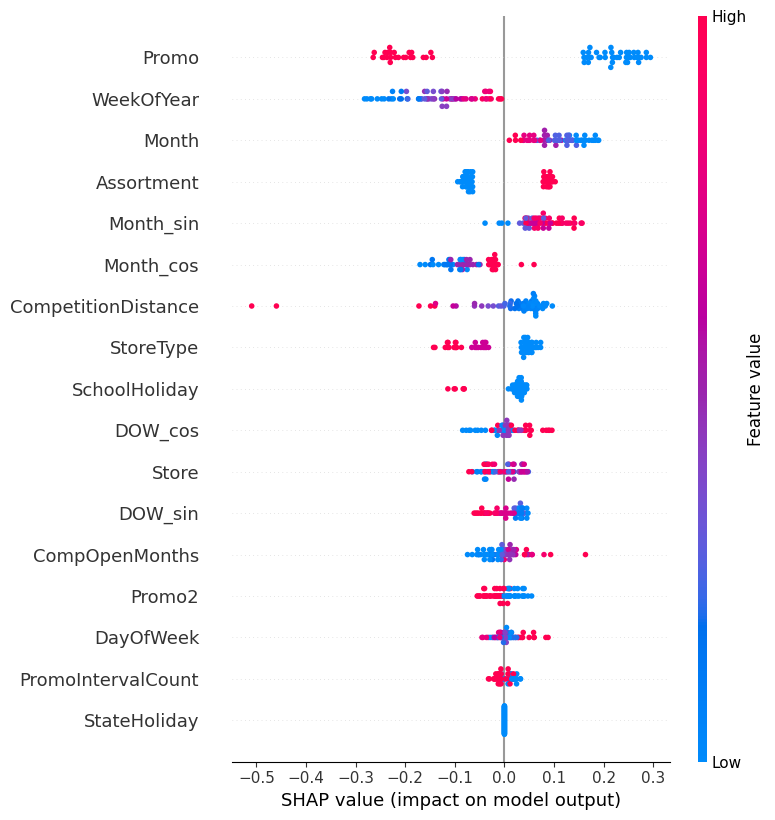

In [60]:
# =========================
# Cell 18 (FAST) — SHAP on Original Features (Last timestep) using PermutationExplainer
# =========================

!pip -q install shap

import shap
import numpy as np
import torch
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="shap")

# Load tuned TCN on CPU
ckpt = torch.load("best_tcn_tuned.pt", map_location="cpu")
tcn_final.cpu()
tcn_final.load_state_dict(ckpt["model_state"])
tcn_final.eval()

np.random.seed(42)

# --- SMALL samples for speed ---
BG_N = 64
TE_N = 64

bg_idx = np.random.choice(len(X_train), size=min(BG_N, len(X_train)), replace=False)
te_idx = np.random.choice(len(X_val),   size=min(TE_N, len(X_val)),   replace=False)

X_bg = X_train[bg_idx]  # [B, T, F] scaled
X_te = X_val[te_idx]

baseline_seq = X_bg.mean(axis=0).astype(np.float32)  # [T, F]

Z_bg = X_bg[:, -1, :].astype(np.float32)  # last step features
Z_te = X_te[:, -1, :].astype(np.float32)

# Model function: replace last timestep in a fixed baseline sequence
def model_f(Z_numpy):
    Z_numpy = np.asarray(Z_numpy, dtype=np.float32)  # [N, F]
    N, F = Z_numpy.shape
    seq = np.repeat(baseline_seq[None, :, :], repeats=N, axis=0)  # [N, T, F]
    seq[:, -1, :] = Z_numpy

    with torch.no_grad():
        yhat = tcn_final(torch.tensor(seq, dtype=torch.float32))  # [N, H] scaled
        yhat = yhat.numpy()

    # scalar output for explanation: mean over horizon
    return yhat.mean(axis=1)  # [N]

# PermutationExplainer is MUCH faster than KernelExplainer
explainer = shap.PermutationExplainer(model_f, Z_bg)

# max_evals controls speed (lower = faster)
shap_values = explainer(Z_te, max_evals=200)

shap.summary_plot(shap_values.values, Z_te, feature_names=feature_cols, show=True)